<a href="https://colab.research.google.com/github/matijairv/challenge2-parte2-data-science-LATAM/blob/main/TelecomX-Parte2_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 🛠️ Preparación de los Datos

En esta etapa se realiza el proceso de preparación del dataset para su utilización en modelos de Machine Learning. El objetivo es asegurar que los datos estén correctamente estructurados, que las variables sean interpretables por los algoritmos y que la variable objetivo esté definida adecuadamente.

Este proceso incluye la carga del dataset tratado previamente, la eliminación de columnas irrelevantes, la transformación de variables categóricas a formato numérico y el análisis de la distribución de la variable objetivo.

## 1.1 Extracción del Archivo Tratado

En esta sección se carga el archivo CSV que contiene los datos previamente limpiados y transformados en la primera parte del desafío. Este dataset ya incluye las correcciones realizadas durante el proceso de ETL (Extracción, Transformación y Carga), así como las variables necesarias para el análisis.

Cargar el dataset tratado garantiza la consistencia entre el análisis exploratorio realizado anteriormente y la etapa de modelado predictivo.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datos_tratados.csv")

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
display(df.head())

Dataset cargado correctamente.
Filas: 7043, Columnas: 22


,ID_Cliente,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Cliente          7043 non-null   object 
 1   Abandono            7043 non-null   object 
 2   Genero              7043 non-null   object 
 3   Adulto_Mayor        7043 non-null   int64  
 4   Tiene_Pareja        7043 non-null   object 
 5   Tiene_Dependientes  7043 non-null   object 
 6   Meses_Contrato      7043 non-null   int64  
 7   PhoneService        7043 non-null   object 
 8   MultipleLines       7043 non-null   object 
 9   InternetService     7043 non-null   object 
 10  OnlineSecurity      7043 non-null   object 
 11  OnlineBackup        7043 non-null   object 
 12  DeviceProtection    7043 non-null   object 
 13  TechSupport         7043 non-null   object 
 14  StreamingTV         7043 non-null   object 
 15  StreamingMovies     7043 non-null   object 
 16  Contra

## 1.2 Eliminación de Columnas Irrelevantes

Antes de entrenar modelos de Machine Learning, es importante eliminar aquellas columnas que no aportan valor predictivo.

En este caso, la columna ID_Cliente corresponde únicamente a un identificador único de cada cliente. Este tipo de variables no contiene información útil para predecir el abandono y puede introducir ruido en el modelo.

Por esta razón, se elimina del dataset antes de continuar con el proceso de modelado.

In [40]:
df_modelo = df.drop(columns=["ID_Cliente"])

print("Columna ID_Cliente eliminada correctamente.")
print(f"Nueva dimensión del dataset: {df_modelo.shape}")

Columna ID_Cliente eliminada correctamente.
Nueva dimensión del dataset: (7043, 21)


## 1.3 Encoding

Los algoritmos de Machine Learning requieren que las variables de entrada estén en formato numérico. Sin embargo, el dataset contiene varias variables categóricas representadas mediante texto.

Para resolver esto, se aplica un proceso de codificación (encoding) utilizando la técnica One-Hot Encoding, que transforma cada categoría en una nueva variable binaria.

Además, la variable objetivo Abandono se convierte a formato binario:

* 0 → cliente permanece en el servicio

* 1 → cliente cancela el servicio

Este paso permite que los modelos interpreten correctamente la información contenida en las variables categóricas.

In [41]:
# Limpieza de la variable objetivo
df_modelo["Abandono"] = df_modelo["Abandono"].str.strip()

# Conversión a variable binaria
df_modelo["Abandono"] = df_modelo["Abandono"].map({"No": 0, "Yes": 1})

# Aplicación de One-Hot Encoding
df_encoded = pd.get_dummies(df_modelo, drop_first=True)

print("Encoding realizado correctamente.")
print(f"Dimensión del dataset después del encoding: {df_encoded.shape}")

display(df_encoded.head())

Encoding realizado correctamente.
Dimensión del dataset después del encoding: (7043, 32)


,Abandono,Adulto_Mayor,Meses_Contrato,Cargo_Mensual,Cargo_Total,Cargo_Diario,Genero_Male,Tiene_Pareja_Yes,Tiene_Dependientes_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.19,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,2.00,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.46,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.27,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.80,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


## 1.4 Verificación de la Proporción de Cancelación (Churn)

Antes de entrenar los modelos, es importante analizar la distribución de la variable objetivo para verificar si existe un desbalance de clases.

Un desbalance ocurre cuando una clase tiene muchos más ejemplos que la otra, lo que puede afectar el rendimiento de algunos algoritmos de clasificación.

En esta sección se calcula la proporción de clientes que abandonaron el servicio frente a aquellos que permanecen, y se visualiza esta distribución mediante un gráfico.

Distribución de la variable objetivo (Abandono):
Abandono
0    5174
1    1869
Name: count, dtype: int64

Proporción porcentual:
Abandono
0    73.46
1    26.54
Name: proportion, dtype: float64


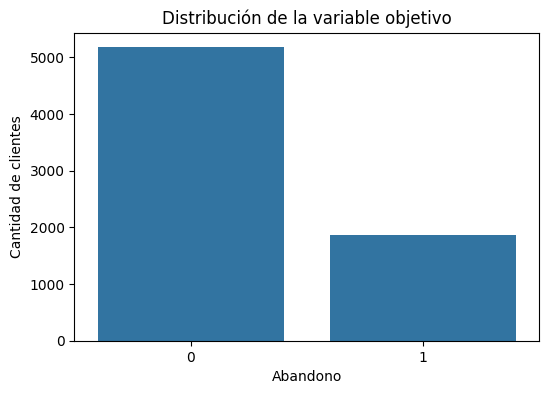

In [42]:
# Reviso si hay desbalance de clases
proporcion_churn = df_modelo["Abandono"].value_counts(normalize=True) * 100
conteo_churn = df_modelo["Abandono"].value_counts()

print("Distribución de la variable objetivo (Abandono):")
print(conteo_churn)
print("\nProporción porcentual:")
print(proporcion_churn.round(2))

# Grafico
plt.figure(figsize=(6,4))
sns.countplot(x="Abandono", data=df_modelo)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Abandono")
plt.ylabel("Cantidad de clientes")

plt.show()

## 1.5 Balanceo de Clases (opcional)

En esta etapa se verificó que existe un desbalance moderado en la variable objetivo. Sin embargo, para una primera aproximación al modelado se decidió no aplicar técnicas de balanceo, con el fin de evaluar primero el desempeño base de los modelos.

## 1.6 Normalización o Estandarización

Algunos algoritmos de Machine Learning son sensibles a la escala de las variables, especialmente aquellos que se basan en cálculos de distancia o en procesos de optimización.

Entre estos modelos se encuentran:

* Regresión Logística

* K-Nearest Neighbors (KNN)

* Support Vector Machines (SVM)

Para estos casos, puede ser necesario aplicar técnicas de normalización o estandarización para asegurar que todas las variables tengan una escala comparable.

Sin embargo, modelos basados en árboles, como Decision Trees o Random Forest, no dependen de la escala de los datos. Por esta razón, la necesidad de aplicar estandarización dependerá de los modelos seleccionados en la etapa de modelado predictivo.

In [43]:
X = df_modelo.drop(columns=["Abandono"])
y = df_modelo["Abandono"]

print("Variables predictoras (X):", X.shape)
print("Variable objetivo (y):", y.shape)

Variables predictoras (X): (7043, 20)
Variable objetivo (y): (7043,)


# 2. 🎯 Correlación y Selección de Variables

## 2.1 Análisis de Correlación

Para comprender mejor las relaciones entre las variables del dataset, se construyó una matriz de correlación utilizando las variables numéricas y binarias más relevantes del modelo. Este análisis permite identificar qué características presentan mayor asociación con la cancelación de clientes y detectar posibles relaciones entre variables predictoras.

La matriz de correlación muestra coeficientes entre -1 y 1, donde valores cercanos a 1 indican una relación positiva fuerte, valores cercanos a -1 indican una relación negativa fuerte y valores cercanos a 0 indican poca o ninguna relación.

A partir de esta visualización es posible observar que variables relacionadas con la antigüedad del cliente, el gasto acumulado y algunos servicios adicionales presentan relaciones más relevantes con la cancelación. Este tipo de análisis es útil para identificar posibles variables predictoras antes de construir los modelos de machine learning.

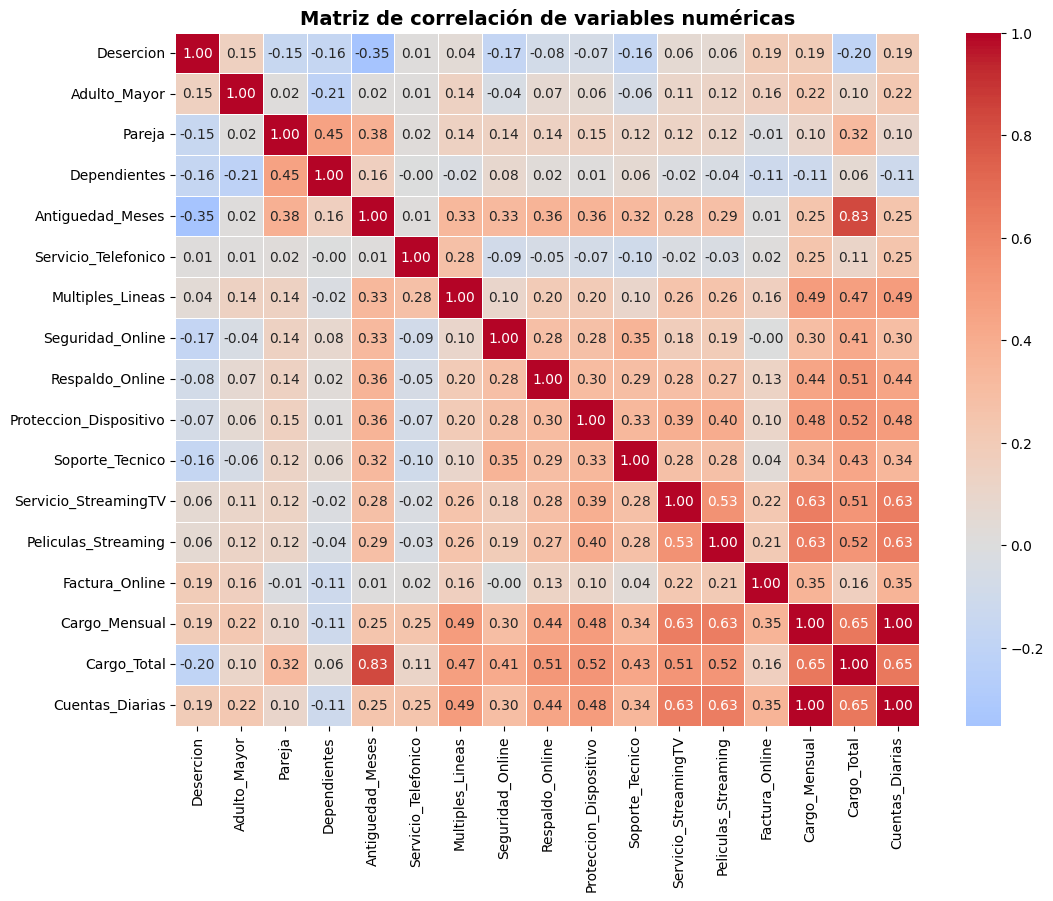

In [48]:

# 2.1 ANÁLISIS DE CORRELACIÓN


import matplotlib.pyplot as plt
import seaborn as sns

# Crear una copia para análisis de correlacion mas legible
df_corr = df_modelo.copy()

# Convertir variables binarias/categoricas clave a formato numérico
df_corr["Genero"] = df_corr["Genero"].map({"Female": 0, "Male": 1})
df_corr["Tiene_Pareja"] = df_corr["Tiene_Pareja"].map({"No": 0, "Yes": 1})
df_corr["Tiene_Dependientes"] = df_corr["Tiene_Dependientes"].map({"No": 0, "Yes": 1})
df_corr["PhoneService"] = df_corr["PhoneService"].map({"No": 0, "Yes": 1})
df_corr["MultipleLines"] = df_corr["MultipleLines"].map({
    "No": 0,
    "Yes": 1,
    "No phone service": 0
})
df_corr["OnlineSecurity"] = df_corr["OnlineSecurity"].map({
    "No": 0,
    "Yes": 1,
    "No internet service": 0
})
df_corr["OnlineBackup"] = df_corr["OnlineBackup"].map({
    "No": 0,
    "Yes": 1,
    "No internet service": 0
})
df_corr["DeviceProtection"] = df_corr["DeviceProtection"].map({
    "No": 0,
    "Yes": 1,
    "No internet service": 0
})
df_corr["TechSupport"] = df_corr["TechSupport"].map({
    "No": 0,
    "Yes": 1,
    "No internet service": 0
})
df_corr["StreamingTV"] = df_corr["StreamingTV"].map({
    "No": 0,
    "Yes": 1,
    "No internet service": 0
})
df_corr["StreamingMovies"] = df_corr["StreamingMovies"].map({
    "No": 0,
    "Yes": 1,
    "No internet service": 0
})
df_corr["PaperlessBilling"] = df_corr["PaperlessBilling"].map({"No": 0, "Yes": 1})

# Seleccionar variables mas importantes para el analisis
columnas_corr = [
    "Abandono",
    "Adulto_Mayor",
    "Tiene_Pareja",
    "Tiene_Dependientes",
    "Meses_Contrato",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "Cargo_Mensual",
    "Cargo_Total",
    "Cargo_Diario"
]

# Renombrar columnas para visualización más clara
df_corr = df_corr[columnas_corr].rename(columns={
    "Abandono": "Desercion",
    "Adulto_Mayor": "Adulto_Mayor",
    "Tiene_Pareja": "Pareja",
    "Tiene_Dependientes": "Dependientes",
    "Meses_Contrato": "Antiguedad_Meses",
    "PhoneService": "Servicio_Telefonico",
    "MultipleLines": "Multiples_Lineas",
    "OnlineSecurity": "Seguridad_Online",
    "OnlineBackup": "Respaldo_Online",
    "DeviceProtection": "Proteccion_Dispositivo",
    "TechSupport": "Soporte_Tecnico",
    "StreamingTV": "Servicio_StreamingTV",
    "StreamingMovies": "Peliculas_Streaming",
    "PaperlessBilling": "Factura_Online",
    "Cargo_Mensual": "Cargo_Mensual",
    "Cargo_Total": "Cargo_Total",
    "Cargo_Diario": "Cuentas_Diarias"
})

# Matriz de correlación
matriz_corr = df_corr.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación de variables numéricas", fontsize=14, fontweight="bold")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## 2.2 Análisis Dirigido

Además de la matriz de correlación general, se realizó un análisis dirigido para examinar la relación entre variables específicas del comportamiento del cliente y la cancelación del servicio. En particular, se analizaron la antigüedad del cliente en la empresa (Meses_Contrato) y el gasto total acumulado (Cargo_Total).

Los diagramas de caja permiten comparar la distribución de estas variables entre los clientes que permanecen en la empresa y aquellos que cancelaron el servicio. A partir de esta visualización se observa que los clientes que abandonan tienden a presentar menor antigüedad en la compañía, lo que sugiere que el riesgo de cancelación es mayor durante los primeros meses de relación con el servicio.

De manera similar, los clientes que cancelan muestran un gasto total acumulado menor, lo que refuerza la idea de que la cancelación suele ocurrir en etapas tempranas del ciclo de vida del cliente. Este comportamiento sugiere la importancia de estrategias de fidelización durante los primeros meses de contrato.

/tmp/ipykernel_182/2602831815.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_182/2602831815.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


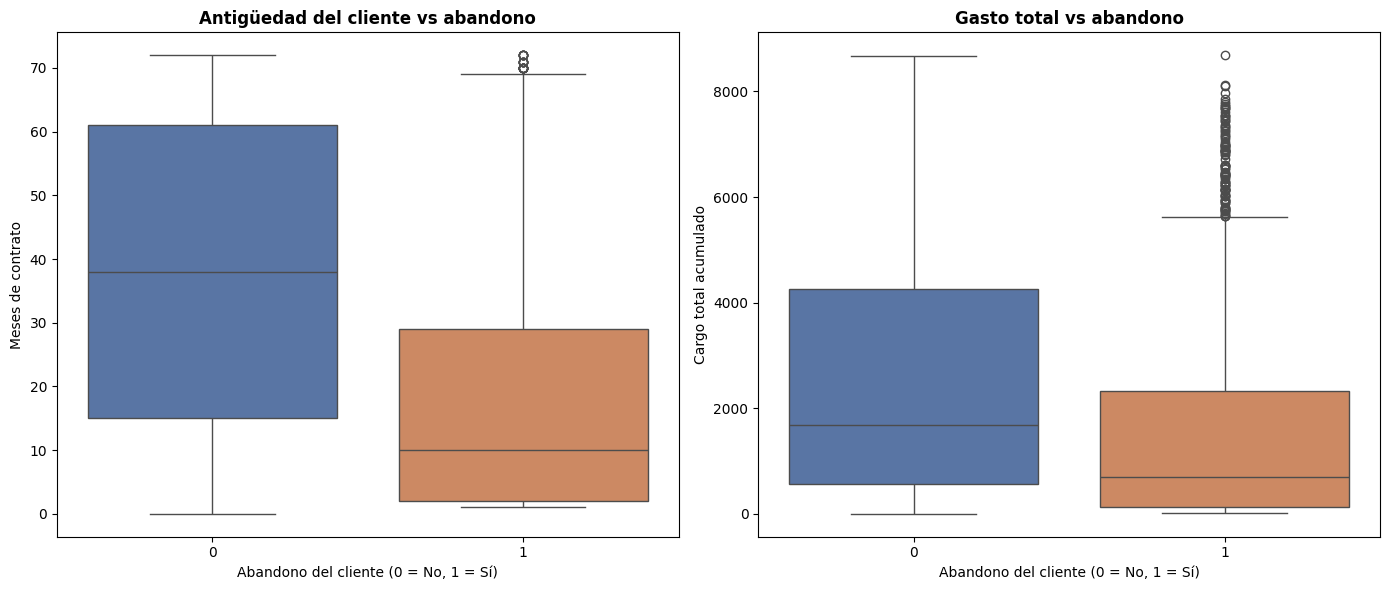

In [50]:
# 2.2 ANÁLISIS DIRIGIDO


import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Paleta de colores
palette = ["#4C72B0", "#DD8452"]  # azul = permanece, naranja = abandona


# Antigüedad vs abandono
sns.boxplot(
    data=df_modelo,
    x="Abandono",
    y="Meses_Contrato",
    palette=palette,
    ax=axes[0]
)

axes[0].set_title("Antigüedad del cliente vs abandono", fontweight="bold")
axes[0].set_xlabel("Abandono del cliente (0 = No, 1 = Sí)")
axes[0].set_ylabel("Meses de contrato")


# Gasto total vs abandono
sns.boxplot(
    data=df_modelo,
    x="Abandono",
    y="Cargo_Total",
    palette=palette,
    ax=axes[1]
)

axes[1].set_title("Gasto total vs abandono", fontweight="bold")
axes[1].set_xlabel("Abandono del cliente (0 = No, 1 = Sí)")
axes[1].set_ylabel("Cargo total acumulado")

plt.tight_layout()
plt.show()

## 3. 🤖 Modelado Predictivo

## 3.1 Separación de Datos

En esta etapa se separó el conjunto de datos en dos subconjuntos: uno destinado al entrenamiento de los modelos y otro para su evaluación. Esta división permite medir la capacidad del modelo para generalizar a datos no vistos previamente.

Se utilizó una división del 80% para entrenamiento y 20% para prueba, una proporción común en problemas de clasificación. Además, se empleó la técnica de estratificación, asegurando que la proporción de clientes que cancelan y los que permanecen se mantenga similar en ambos subconjuntos. Esto es especialmente importante cuando existe cierto desbalance entre las clases.

In [51]:
from sklearn.model_selection import train_test_split

# Variables predictoras y variable objetivo
X = df_encoded.drop(columns=["Abandono"])
y = df_encoded["Abandono"]

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5634, 31)
Datos de prueba: (1409, 31)


## 3.2 Creación de Modelos

Para predecir la cancelación de clientes se implementaron dos modelos de clasificación con enfoques diferentes.

El primer modelo corresponde a Regresión Logística, un algoritmo ampliamente utilizado para problemas de clasificación binaria. Este modelo estima la probabilidad de que un cliente abandone el servicio a partir de una combinación lineal de las variables predictoras.

El segundo modelo corresponde a Random Forest, un algoritmo basado en conjuntos de árboles de decisión. Este modelo es capaz de capturar relaciones no lineales entre variables y suele ofrecer un buen desempeño en problemas de clasificación tabular.

El uso de dos modelos distintos permite comparar enfoques y seleccionar el que mejor se adapte al problema.

### Modelo 1 — Regresión Logística

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
from sklearn.linear_model import LogisticRegression

print("Entrenando modelo: Regresión Logística...")

modelo_logistico = LogisticRegression(max_iter=2000, random_state=42)

modelo_logistico.fit(X_train_scaled, y_train)

pred_log = modelo_logistico.predict(X_test_scaled)

print("Modelo de Regresión Logística entrenado correctamente.")
print("Predicciones generadas con éxito.")

Entrenando modelo: Regresión Logística...
Modelo de Regresión Logística entrenado correctamente.
Predicciones generadas con éxito.


### Modelo 2 — Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier

print("Entrenando modelo: Random Forest...")

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

print("Modelo Random Forest entrenado correctamente.")
print("Predicciones generadas con éxito.")

Entrenando modelo: Random Forest...
Modelo Random Forest entrenado correctamente.
Predicciones generadas con éxito.


## 3.3 Evaluación de los Modelos

Una vez entrenados los modelos, se evaluó su desempeño utilizando diversas métricas de clasificación. Estas métricas permiten analizar diferentes aspectos del rendimiento del modelo:

* Accuracy (Exactitud): proporción de predicciones correctas.

* Precision: capacidad del modelo para evitar falsos positivos.

* Recall: capacidad del modelo para identificar correctamente los casos de cancelación.

* F1-score: equilibrio entre precisión y recall.

* Matriz de confusión: representación visual de aciertos y errores del modelo.

El análisis comparativo de estas métricas permite determinar cuál modelo ofrece mejores resultados para la predicción de cancelación de clientes.

### Evaluación — Regresión Logística

In [63]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("=== REGRESIÓN LOGÍSTICA ===")

acc_log = accuracy_score(y_test, pred_log)
prec_log = precision_score(y_test, pred_log)
rec_log = recall_score(y_test, pred_log)
f1_log = f1_score(y_test, pred_log)
cm_log = confusion_matrix(y_test, pred_log)

print(f"Accuracy: {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall: {rec_log:.4f}")
print(f"F1-score: {f1_log:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, pred_log))

print("\nMatriz de confusión:")
print(cm_log)

=== REGRESIÓN LOGÍSTICA ===
Accuracy: 0.7928
Precision: 0.6331
Recall: 0.5214
F1-score: 0.5718

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Matriz de confusión:
[[922 113]
 [179 195]]


### Evaluación — Random Forest

In [64]:
print("=== RANDOM FOREST ===")

acc_rf = accuracy_score(y_test, pred_rf)
prec_rf = precision_score(y_test, pred_rf)
rec_rf = recall_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)
cm_rf = confusion_matrix(y_test, pred_rf)

print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, pred_rf))

print("\nMatriz de confusión:")
print(cm_rf)

=== RANDOM FOREST ===
Accuracy: 0.7885
Precision: 0.6319
Recall: 0.4866
F1-score: 0.5498

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Matriz de confusión:
[[929 106]
 [192 182]]


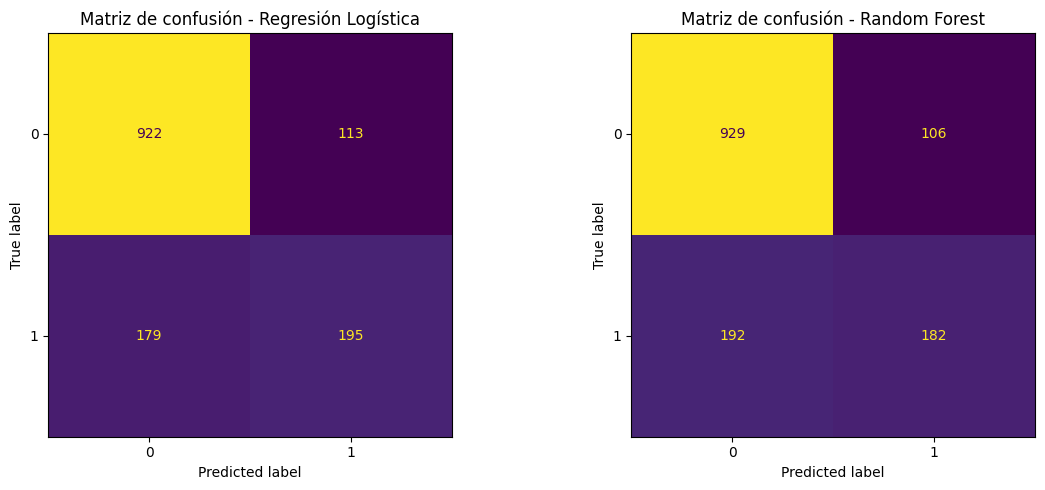

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay(confusion_matrix=cm_log).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión - Regresión Logística")

ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Matriz de confusión - Random Forest")

plt.tight_layout()
plt.show()

,Regresión Logística,Random Forest
Accuracy,0.792761,0.788502
Precision,0.633117,0.631944
Recall,0.521390,0.486631
F1-score,0.571848,0.549849


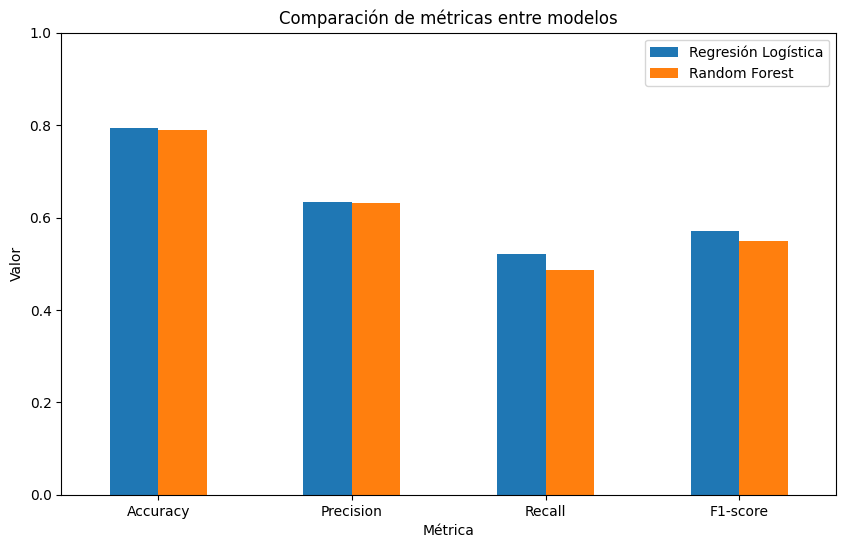

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

metricas_modelos = pd.DataFrame({
    "Regresión Logística": [acc_log, prec_log, rec_log, f1_log],
    "Random Forest": [acc_rf, prec_rf, rec_rf, f1_rf]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])

display(metricas_modelos)

metricas_modelos.plot(kind="bar", figsize=(10,6))

plt.title("Comparación de métricas entre modelos")
plt.ylabel("Valor")
plt.xlabel("Métrica")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

# 4. 📋 Interpretación y Conclusiones

## 4.1 Análisis de la Importancia de las Variables

Para interpretar los factores que influyen en la cancelación de clientes se analizaron los coeficientes del modelo de Regresión Logística, ya que este modelo permite observar la contribución de cada variable en la predicción de la cancelación. Los coeficientes positivos indican que la variable aumenta la probabilidad de abandono, mientras que los coeficientes negativos indican una relación con la permanencia del cliente.

Este análisis permite identificar las características del servicio, del comportamiento del cliente y del nivel de gasto que están más asociadas con la cancelación, lo cual es fundamental para proponer estrategias de retención.

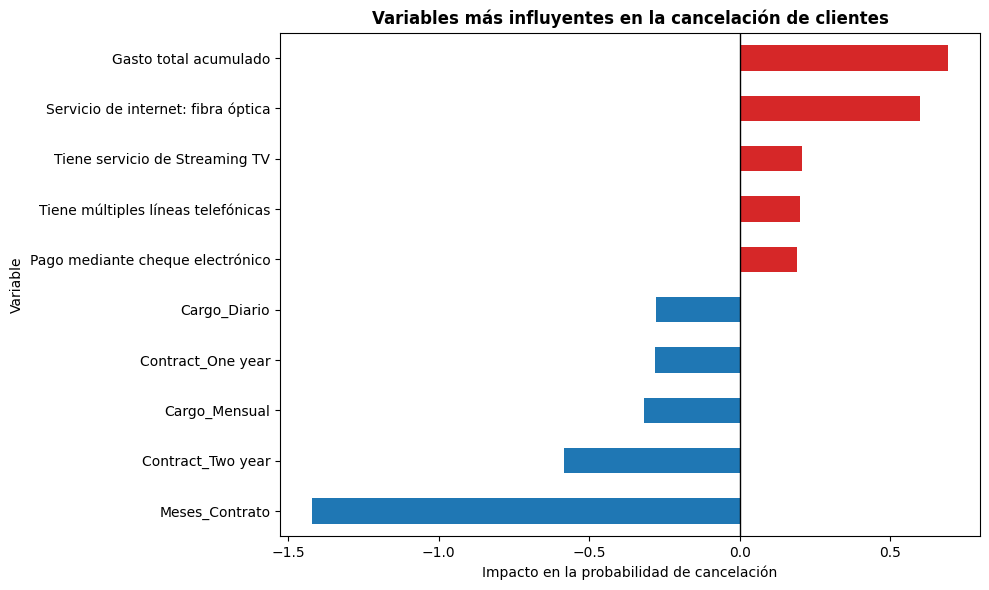

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Coeficientes del modelo
coeficientes = pd.Series(modelo_logistico.coef_[0], index=X.columns)

# Nombres legibles
nombres_legibles = {
    "Cargo_Total": "Gasto total acumulado",
    "InternetService_Fiber optic": "Servicio de internet: fibra óptica",
    "StreamingTV_Yes": "Tiene servicio de Streaming TV",
    "StreamingMovies_Yes": "Tiene servicio de películas en streaming",
    "MultipleLines_Yes": "Tiene múltiples líneas telefónicas",
    "MultipleLines_No phone service": "Sin servicio telefónico",
    "PaymentMethod_Electronic check": "Pago mediante cheque electrónico",
    "PaperlessBilling_Yes": "Factura electrónica",
    "Adulto_Mayor": "Cliente adulto mayor",
    "DeviceProtection_Yes": "Tiene protección de dispositivos"
}

coeficientes.index = coeficientes.index.map(lambda x: nombres_legibles.get(x, x))

# Seleccionar variables más influyentes por magnitud
top = coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).index).head(10)

# Ordenar para graficar
top = top.sort_values()

# Colores según impacto
colores = ["#d62728" if v > 0 else "#1f77b4" for v in top]

plt.figure(figsize=(10,6))
top.plot(kind="barh", color=colores)

plt.axvline(0, color="black", linewidth=1)

plt.title("Variables más influyentes en la cancelación de clientes", fontweight="bold")
plt.xlabel("Impacto en la probabilidad de cancelación")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

**🔴 Variables que aumentan la probabilidad de abandono (impacto positivo)**

* Gasto total acumulado

* Internet fibra óptica

* Streaming TV

* Múltiples líneas telefónicas

* Pago con cheque electrónico

**Interpretación posible:** clientes con servicios más complejos o con ciertos métodos de pago presentan mayor riesgo de churn.

**🔵 Variables que reducen la probabilidad de abandono (impacto negativo)**

* Meses de contrato (antigüedad) ← la más fuerte

* Contrato de dos años

* Cargo mensual

* Contrato de un año

* Cargo diario

**Interpretación clave:** La variable más fuerte del modelo es Meses_Contrato (antigüedad), con coeficiente negativo grande.

Esto significa que:

**Cuanto más tiempo lleva un cliente en la empresa, menor es la probabilidad de que cancele el servicio.**

## 4.2 Conclusión

## 📑 Informe Final

### 🎯 Principales factores que influyen en la cancelación de clientes

A partir del análisis de los datos y del modelo predictivo desarrollado, se identificaron varios factores que influyen significativamente en la probabilidad de que un cliente cancele su servicio en Telecom X.

* **Antigüedad del cliente**
Es el factor más influyente. Los clientes con menor tiempo en la empresa presentan una probabilidad significativamente mayor de cancelar el servicio. A medida que aumenta la antigüedad, la probabilidad de abandono disminuye considerablemente, lo que indica que los clientes tienden a volverse más leales con el tiempo.

* **Tipo de contrato**
Los clientes con contratos mensuales muestran una mayor tendencia a cancelar el servicio. En cambio, los contratos de uno o dos años están asociados a una menor probabilidad de cancelación, ya que implican un mayor compromiso con la empresa.

* **Servicio de internet por fibra óptica**
Los clientes que utilizan este tipo de servicio presentan una mayor probabilidad de cancelar. Esto podría estar relacionado con expectativas más altas sobre la calidad del servicio o con una mayor competencia en este segmento del mercado.

* **Servicios adicionales (Streaming, múltiples líneas, etc.)**
El uso de ciertos servicios adicionales está relacionado con cambios en el comportamiento de cancelación. Estos servicios pueden aumentar el valor percibido del servicio, pero también pueden reflejar perfiles de consumo más exigentes.

* **Facturación y métodos de pago**
Variables relacionadas con el método de pago y la facturación electrónica también muestran influencia en la cancelación, lo que sugiere que la experiencia de pago y facturación puede afectar la permanencia del cliente.

---

## 🎯 Recomendaciones estratégicas para Telecom X

A partir de los factores identificados, se proponen varias estrategias orientadas a reducir la cancelación de clientes y mejorar la retención.

* **Fortalecer la experiencia durante los primeros meses**
Dado que la mayor tasa de cancelación ocurre en clientes nuevos, es recomendable implementar programas de acompañamiento inicial, soporte prioritario y seguimiento durante los primeros meses de servicio.

* **Incentivar contratos de mayor duración**
Ofrecer beneficios o descuentos a clientes que opten por contratos anuales o bianuales puede ayudar a reducir la cancelación y aumentar la estabilidad de la base de clientes.

* **Evaluar la experiencia del servicio de fibra óptica**
El mayor riesgo de cancelación en este segmento sugiere la necesidad de analizar la calidad del servicio, la atención al cliente y las expectativas del usuario en este tipo de conexión.

* **Promover servicios de valor agregado**
Los servicios adicionales pueden aumentar la fidelización cuando aportan valor real al cliente. Diseñar paquetes integrados o promociones puede fortalecer la relación con los usuarios.

* **Implementar sistemas de alerta temprana**
El modelo predictivo desarrollado puede utilizarse como herramienta de monitoreo para identificar clientes con alta probabilidad de cancelar y aplicar estrategias de retención de forma anticipada.

---

## ⭐ Modelo seleccionado

Entre los modelos evaluados, **la Regresión Logística fue seleccionada como el modelo principal** debido a su buen rendimiento predictivo y a su facilidad de interpretación.

Aunque Random Forest presentó un desempeño similar en términos de exactitud, la Regresión Logística permite comprender con mayor claridad **qué variables influyen en la cancelación**, lo cual es especialmente valioso para la toma de decisiones estratégicas dentro de la empresa.

Gracias a esta interpretabilidad, el modelo no solo permite predecir cancelaciones, sino también **identificar oportunidades concretas para mejorar la retención de clientes**.

---

*En conclusión, el uso de análisis de datos y modelos predictivos permite a Telecom X **anticiparse al abandono de clientes**, comprender mejor los factores que lo provocan y diseñar estrategias de retención basadas en evidencia. Implementar estas acciones puede traducirse en una reducción significativa de la cancelación y en una mejora en la fidelización de los clientes.*
